In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, recall_score, classification_report, f1_score, confusion_matrix, precision_score
)

In [4]:
df = pd.read_csv('Breast_Cancer_Wisconsin_Dataset.csv')
df.head()
df.shape

(569, 33)

In [9]:
df['diag'] = df['diagnosis'].map({'M' : 1, 'B' : 0})

X = df.drop(columns=['diag', 'diagnosis'])
y = df['diag']

0    1
1    1
2    1
3    1
4    1
Name: diag, dtype: int64

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20)

In [13]:
model = DecisionTreeClassifier(
    max_depth=4,
    random_state=20
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
print(f"The accuracy of the model is {accuracy:.3f} which is {accuracy*100:.1f}%")

The accuracy of the model is 0.912 which is 91.2%


In [15]:
cm = confusion_matrix(y_test, predictions)
print("Confusion Matrix is: ")
print(cm)
print()
print(f"Correct: {cm[0,0] + cm[1,1]}")
print(f"Wrong: {cm[0,1] + cm[1,0]}")

Confusion Matrix is: 
[[60  6]
 [ 4 44]]

Correct: 104
Wrong: 10


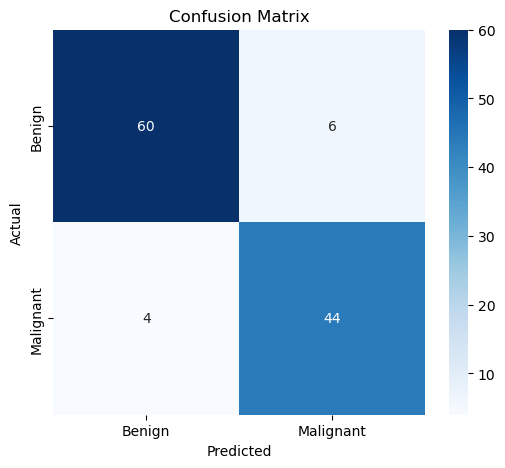

In [17]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malignant'], yticklabels=['Benign', 'Malignant'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

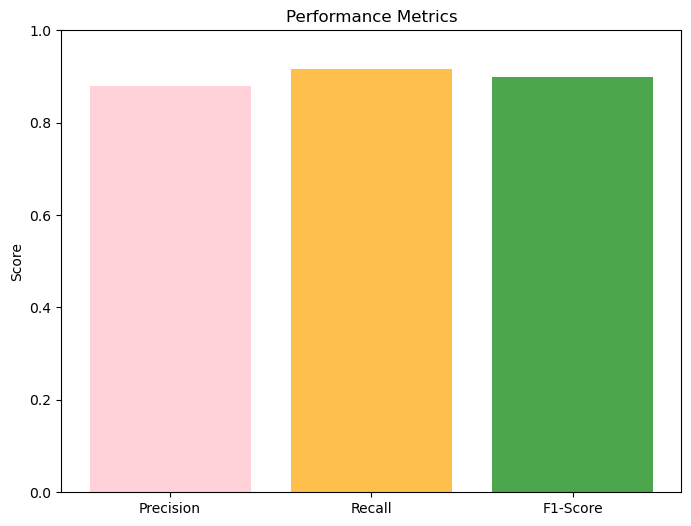

In [20]:
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)

plt.figure(figsize=(8,6))
metrics = ['Precision', 'Recall', 'F1-Score']
values = [precision, recall, f1]
plt.bar(metrics, values, color=['pink', 'orange', 'green'], alpha=0.7)
plt.ylim(0,1)
plt.title('Performance Metrics')
plt.ylabel('Score')
plt.show()